#### Outline
- [Import Required Libraries](#Import-Required-Libraries)
- [Step 2 Load the Dataset](#Step-2-Load-the-Dataset)
- [Step 3 Initial Data Exploration](#Step-3-Initial-Data-Exploration)
- [Step 4 Data Cleaning](#Step-4-Data-Cleaning)
- [Step 5 Feature Engineering](#Step-5-Feature-Engineering)
- [Step 6 Exploratory Data Analysis](#Step-6-Exploratory-Data-Analysis)
- [Step 7 Business Insight from (EDA)](#Step-7-Business-Insight-from-(EDA))
- [Step 9 Train Test Split](#Step-9-Train-Test-Split)
- [Step 10 Build the Preprocessing Pipeline](#Step-10-Build-the-Preprocessing-Pipeline)
- [Step 11 Build Machine Learning Models](#Step-11-Build-Machine-Learning-Models)
- [Step 12 Train the Models](#Step-12-Train-the-Models)
- [Step 13 Model Evaluation](#Step-13-Model-Evaluation)
- [Step 14 Residual Analysis](#Step-14-Residual-Analysis)
- [Step 15 Feature Importance](#Step-15-Feature-Importance)
- [Step 16 Hyperparameter Tuning](#Step-16-Hyperparameter-Tuning)
- [Step 17 Save the Best Model](#Step-17-Save-the-Best-Model)
- [Step 18 Predict Selling Price of a New Vehicle](#Step-18-Predict-Selling-Price-of-a-New-Vehicle)
- [Step 19 Business Interpretation](#Step-19-Business-Interpretation)
- [Step 20 Business Recommendation](#Step-20-Business-Recommendation)
- [Step 21 Project Conculsion](#Step-8-Feature-Selection)
- [Step 22 Project Limitations and Future Improvements](#Step-22-Project-Limitations-and-Future-Improvements)

#### Step 1 Import Required Libraries

In [230]:

# STEP 1: IMPORT REQUIRED LIBRARIES
# Project: Car Selling Price Prediction

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display Options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot Style
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


#### Step 2 Load the Dataset

In [231]:
# ============================================================
# STEP 2: LOAD DATASET
# ============================================================

# 2.1 Load the dataset and Display First five rows
df = pd.read_csv(r'C:\Users\Emeka\Desktop\car\car_price_train.csv')

# Display first five rows
df.head()

,VehicleID,Location,Maker,Model,Year,Colour,Amount (Million Naira),Type,Distance
0,VHL12546,Abuja,Honda,Accord Coupe EX V-6,"2,011",Silver,2.20,Nigerian Used,NaN
1,VHL18827,Ibadan,Hyundai,Sonata,"2,012",Silver,3.50,Nigerian Used,"125,000"
2,VHL19499,Lagos,Lexus,RX 350,"2,010",Red,9.20,Foreign Used,"110,852"
3,VHL17991,Abuja,Mercedes-Benz,GLE-Class,"2,017",Blue,22.80,Foreign Used,"30,000"
4,VHL12170,Ibadan,Toyota,Highlander,"2,002",Red,2.60,Nigerian Used,"125,206"


In [232]:
# Check for shape
# Dataset dimensions
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 7205
Number of Columns : 9


#### Step 3 Initial Data Exploration

In [233]:
# 3.1 View Dataset

# Display first 10 records
df.head(10)

,VehicleID,Location,Maker,Model,Year,Colour,Amount (Million Naira),Type,Distance
0,VHL12546,Abuja,Honda,Accord Coupe EX V-6,"2,011",Silver,2.20,Nigerian Used,NaN
1,VHL18827,Ibadan,Hyundai,Sonata,"2,012",Silver,3.50,Nigerian Used,"125,000"
2,VHL19499,Lagos,Lexus,RX 350,"2,010",Red,9.20,Foreign Used,"110,852"
3,VHL17991,Abuja,Mercedes-Benz,GLE-Class,"2,017",Blue,22.80,Foreign Used,"30,000"
4,VHL12170,Ibadan,Toyota,Highlander,"2,002",Red,2.60,Nigerian Used,"125,206"
5,VHL19996,Lagos,Toyota,Venza V6,"2,011",Black,7.50,Foreign Used,NaN
6,VHL16314,Lagos,Lexus,LX 570 AWD,"2,019",Black,79.00,Foreign Used,NaN
7,VHL14299,Abuja,Toyota,Avalon,"2,015",Gold,9.00,Foreign Used,NaN
8,VHL15637,Lagos,Toyota,Sienna,"2,012",Blue,7.76,Foreign Used,"350,882"
9,VHL15752,Ibadan,Mercedes-Benz,C240 Matt,"2,004",Black,2.50,Foreign Used,"179,638"


In [235]:
# 3.2 View Last Records

df.tail(10)

,VehicleID,Location,Maker,Model,Year,Colour,Amount (Million Naira),Type,Distance
7195,VHL18811,Abuja,Toyota,Camry,"2,008",Black,2.30,Nigerian Used,"80,000"
7196,VHL10312,Lagos,Acura,MDX,"2,007",Gold,4.20,Foreign Used,"83,695"
7197,VHL18453,Lagos,Lexus,RX,"2,005",Black,5.00,Foreign Used,"30,000"
7198,VHL12205,Lagos,Mercedes-Benz,M Class ML 350 4Matic,"2,007",Black,5.50,Foreign Used,"114,257"
7199,VHL17562,Lagos,Toyota,4-Runner Limited V6,"2,007",Blue,5.80,Foreign Used,NaN
7200,VHL14329,Abuja,Honda,Civic,"2,018",Gray,5.70,Foreign Used,"65,000"
7201,VHL10637,Abuja,BMW,X3,"2,007",White,4.00,Nigerian Used,"200,000"
7202,VHL19734,Abuja,Toyota,RAV4 2.5 Limited 4x4,"2,010",Black,2.85,Nigerian Used,NaN
7203,VHL15569,Lagos,Mercedes-Benz,GLK-Class 350,"2,012",Black,8.65,Foreign Used,"85,750"
7204,VHL15246,Abuja,Honda,Accord Crosstour,"2,012",Gray,3.38,Nigerian Used,"83,308"


In [236]:
# 3.3 View Dataset Randomly

df.sample(20)

,VehicleID,Location,Maker,Model,Year,Colour,Amount (Million Naira),Type,Distance
6942,VHL17335,Abuja,Mercedes-Benz,E350,"2,007",Silver,2.70,Nigerian Used,NaN
5047,VHL18934,Lagos,Lexus,ES 350 FWD,"2,013",White,8.70,Foreign Used,"70,563"
4879,VHL12448,Lagos,Lexus,ES 350 FWD,"2,013",Silver,9.00,Foreign Used,"117,869"
2033,VHL12116,Abuja,Land Rover,Rover Discovery Series II SE AWD,"2,002",Green,3.50,Nigerian Used,NaN
2794,VHL10194,Ibadan,Hyundai,Santa Fe 2.7 V6,"2,009",Green,3.15,Foreign Used,"113,451"
7133,VHL10453,Abuja,Peugeot,407,"2,007",Blue,1.25,Nigerian Used,NaN
2309,VHL19069,Abuja,Toyota,Camry,"2,021",White,30.00,Foreign Used,NaN
2204,VHL19132,Abuja,Toyota,Camry XSE FWD,"2,020",Black,20.00,Foreign Used,NaN
7187,VHL10003,Lagos,Toyota,Camry XSE FWD (2.5L 4cyl 8AM),"2,018",Gray,18.70,Foreign Used,NaN
6939,VHL10174,Abuja,Toyota,Camry,"2,008",Gold,3.40,Foreign Used,NaN


In [7]:
# From the above dataset, the Distances of some Brand New, Foreign Used and Nigerian Used are not avaliable

In [237]:
# 3.3 Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7205 entries, 0 to 7204
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   VehicleID               7205 non-null   str    
 1   Location                7205 non-null   str    
 2   Maker                   7205 non-null   str    
 3   Model                   7205 non-null   str    
 4   Year                    7184 non-null   str    
 5   Colour                  7205 non-null   str    
 6   Amount (Million Naira)  7188 non-null   float64
 7   Type                    7008 non-null   str    
 8   Distance                4845 non-null   str    
dtypes: float64(1), str(8)
memory usage: 506.7 KB


In [238]:
# 3.4 Statistical Summary

df.describe()

,Amount (Million Naira)
count,7188.00
mean,11.85
std,25.32
min,0.45
25%,3.50
50%,5.65
75%,11.66
max,456.00


In [239]:
# 3.5 Statistical Summary Including Categorical Variables

df.describe(include='object').T

,count,unique,top,freq
VehicleID,7205,5141,VHL16443,5
Location,7205,3,Lagos,3318
Maker,7205,55,Toyota,2742
Model,7205,1223,Camry,651
Year,7184,33,"2,008",755
Colour,7205,21,Black,2128
Type,7008,3,Foreign Used,4896
Distance,4845,3144,"75,000",70


In [240]:
# 3.6 Check Missing Values

# Checking missing values
# We have missing values in Year: 21, Amount: 17, Type: 197, Distance: 2360
df.isnull().sum()

VehicleID                    0
Location                     0
Maker                        0
Model                        0
Year                        21
Colour                       0
Amount (Million Naira)      17
Type                       197
Distance                  2360
dtype: int64

In [241]:
# 3.7 Check Duplicate Records

duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


In [242]:
# 3.8 Check Data Types
# We need to convert Distance to float, Year to integer

df.dtypes

VehicleID                     str
Location                      str
Maker                         str
Model                         str
Year                          str
Colour                        str
Amount (Million Naira)    float64
Type                          str
Distance                      str
dtype: object

In [243]:
# 3.9 Display Unique Values

for col in df.select_dtypes(include='object'):
    print(f"\n{col}")
    print("-"*40)
    print(df[col].unique())


VehicleID
----------------------------------------
<StringArray>
['VHL12546', 'VHL18827', 'VHL19499', 'VHL17991', 'VHL12170', 'VHL19996',
 'VHL16314', 'VHL14299', 'VHL15637', 'VHL15752',
 ...
 'VHL13650', 'VHL11569', 'VHL12389', 'VHL16077', 'VHL10003', 'VHL17307',
 'VHL11880', 'VHL12205', 'VHL17562', 'VHL15246']
Length: 5141, dtype: str

Location
----------------------------------------
<StringArray>
['Abuja', 'Ibadan', 'Lagos']
Length: 3, dtype: str

Maker
----------------------------------------
<StringArray>
[        'Honda',       'Hyundai',         'Lexus', 'Mercedes-Benz',
        'Toyota',         'Acura',         'Dodge',        'Nissan',
           'Kia',           'BMW',         'Volvo',          'Ford',
    'Land Rover',       'Lincoln',       'Peugeot',     'Chevrolet',
          'Audi',        'Jaguar',      'Infiniti',       'Porsche',
          'Fiat',      'Maserati',    'Volkswagen',        'Suzuki',
       'Bentley',           'GAC',         'Mazda',         'Scion',

#### Step 4 Data Cleaning

In [244]:
# Convert  the year column from string to integer
# Use replace function to remove the ","
df['Year'] = df['Year'].str.replace(',', '')

In [245]:
# Convert the year column from string to integer
df['Year'] = df['Year'].astype('Int64')

In [246]:
# To fill up the mising Year value, Get the mode of the Year
yr_mode = df['Year'].mode()[0]

In [247]:
# Fill in the missing values in the Amount
# First get the median

amount_median = df['Amount (Million Naira)'].median()
print(amount_median)

5.65


In [248]:
# Fill in the median in the missing spaces
df['Amount (Million Naira)'] = df['Amount (Million Naira)']. fillna(amount_median)

In [249]:
# Fill in the mising values from the Distance
# Convert the Distance to float
# First remove the commas

In [251]:
# First remove the commas in Distance Column
df['Distance'] = df['Distance'].str.replace(',', '')

In [252]:
# Convert the Distance to float
df['Distance'] = df['Distance'].astype(float)

In [26]:
# The NaN in Distance is 32.76%. 
# Non torelance limit starts from 5% - 30%
# torelance limit is less than 2% - 5%
# Since car mileage varies drastically depending on Nigerian Used and Foreign Used
# Also remember that Brown new cars have 0 mileage 0r 10 to 100 klm as delivery mileage

In [27]:
# Lets handle the "Brand New" Separately
# Since they are Brand New, that is no usage, we can assign them "0" value

In [253]:
# Create a missing indicator
df['Distance_missing'] = df['Distance'].isna().astype(int)

In [255]:
# Calculate the median distance of Brand New vehicles

brand_new_median = df.loc[
    (df['Type'] == 'Brand New') &
    (df['Distance'].notna()),
    'Distance'
].median()

# Fill missingBrand New distances with the median

df.loc[
    (df['Type'] == 'Brand New') &
    (df['Distance'].isna()),
    'Distance'
] = brand_new_median



In [256]:
# Use the median Distance within the same Type, Maker, and Model to fill up the distance

# Fill remaing missing values using Type + Maker + Model

df['Distance'] = df['Distance'].fillna(
    df.groupby(['Type', 'Maker', 'Model'])['Distance'].transform('median')
)

In [257]:
# Fallback to Type median

df['Distance'] = df['Distance'].fillna(
    df.groupby('Type')['Distance'].transform('median')
)

In [258]:
# Final Fallback to Type median

df['Distance'] = df['Distance'].fillna(df['Distance'].median())


In [259]:
# Confirm missing Distance

print(df['Distance'].isna().sum())

0


In [260]:
# From the information, 197 values of Type are missing.
# Frist let check the distribution

df['Type'].value_counts(dropna=False)

Type
Foreign Used     4896
Nigerian Used    1895
Brand New         217
NaN               197
Name: count, dtype: int64

In [261]:
# Infer Type using Maker, Model, Year

df['Type'] = df['Type'].fillna(
    df.groupby(['Maker', 'Model', 'Year'])['Type'].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
)

In [263]:
# Remove Duplicate Records (if any)

#df = df.drop_duplicates()

#print("Dataset Shape:", df.shape)

In [264]:
# 4.2 Verify Missing Values

df.isnull().sum()



VehicleID                  0
Location                   0
Maker                      0
Model                      0
Year                      21
Colour                     0
Amount (Million Naira)     0
Type                      95
Distance                   0
Distance_missing           0
dtype: int64

In [ ]:
# We are still having missing values 95 in Type, 21 in Year
# Since Year is a numerical variable and strongly related to the vehicle itself, i will use
# the median year of the same Maker and Model

In [265]:
# Fill Year using Maker and Model median

df['Year'] = df['Year'].fillna(
    df.groupby(['Maker', 'Model'])['Year'].transform('median')
)

In [266]:
# Fill remaining using Maker median

df['Year'] = df['Year'].fillna(
    df.groupby('Maker')['Year'].transform('median')
)

In [267]:
# Fill any remaining values with overall median

df['Year'] = df['Year'].fillna(df['Year'].median())


In [268]:
# Convert back to integer

df['Year'] = df['Year'].astype(int)

In [269]:
# Since i have already used Maker, Model and Year . There is likely unique combinations. 
# Let try this
# Fill using Maker and Model

df['Type'] = df['Type']. fillna(
    df.groupby(['Maker', 'Model'])['Type'].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan

    )
)

In [270]:
df.isnull().sum()

VehicleID                  0
Location                   0
Maker                      0
Model                      0
Year                       0
Colour                     0
Amount (Million Naira)     0
Type                      51
Distance                   0
Distance_missing           0
dtype: int64

In [271]:
# Now Type has drop down to 51. Lets try more. Use Maker only

df['Type'] = df['Type']. fillna(
    df.groupby('Maker')['Type'].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan

    )
)


In [272]:
df.isnull().sum()

VehicleID                 0
Location                  0
Maker                     0
Model                     0
Year                      0
Colour                    0
Amount (Million Naira)    0
Type                      3
Distance                  0
Distance_missing          0
dtype: int64

In [273]:
# Now Type has drop down to 3. Lets try more. Use Model only

df['Type'] = df['Type']. fillna(
    df.groupby('Model')['Type'].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan

    )
)



In [274]:
df.isnull().sum()

VehicleID                 0
Location                  0
Maker                     0
Model                     0
Year                      0
Colour                    0
Amount (Million Naira)    0
Type                      3
Distance                  0
Distance_missing          0
dtype: int64

In [275]:
# Still missing 3. 

df['Type'] = df['Type'].fillna(df['Type'].mode()[0])

In [276]:
# Final Check. We have achieved zero missing values at last

print(df.isnull().sum())

VehicleID                 0
Location                  0
Maker                     0
Model                     0
Year                      0
Colour                    0
Amount (Million Naira)    0
Type                      0
Distance                  0
Distance_missing          0
dtype: int64


In [277]:
# 4.3 Check Column Names

df.columns

Index(['VehicleID', 'Location', 'Maker', 'Model', 'Year', 'Colour',
       'Amount (Million Naira)', 'Type', 'Distance', 'Distance_missing'],
      dtype='str')

In [278]:
# 4.4 Standardize Column Names

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.columns

Index(['vehicleid', 'location', 'maker', 'model', 'year', 'colour',
       'amount_(million_naira)', 'type', 'distance', 'distance_missing'],
      dtype='str')

In [279]:
# 4.5 Verify Dataset Again

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7205 entries, 0 to 7204
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   vehicleid               7205 non-null   str    
 1   location                7205 non-null   str    
 2   maker                   7205 non-null   str    
 3   model                   7205 non-null   str    
 4   year                    7205 non-null   int64  
 5   colour                  7205 non-null   str    
 6   amount_(million_naira)  7205 non-null   float64
 7   type                    7205 non-null   str    
 8   distance                7205 non-null   float64
 9   distance_missing        7205 non-null   int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 563.0 KB


#### Step 5 Feature Engineering

In [280]:
# 5.1 Create Vehicle Age

# Remember: Brand-new cars will naturally have vehicle_age = 0. But at times they will not be sold the year of production. 

# Current year
current_year = pd.Timestamp.now().year

# Create Vehicle Age
df["vehicle_age"] = current_year - df["year"]

# Verify
df[["year", "vehicle_age"]].head()

,year,vehicle_age
0,2011,15
1,2012,14
2,2010,16
3,2017,9
4,2002,24


In [281]:
# 5.2 Check Distribution of Vehicle Age

df["vehicle_age"].describe()

count   7205.00
mean      14.97
std        4.85
min        4.00
25%       12.00
50%       15.00
75%       18.00
max       47.00
Name: vehicle_age, dtype: float64

In [282]:
print(df.columns.tolist())

['vehicleid', 'location', 'maker', 'model', 'year', 'colour', 'amount_(million_naira)', 'type', 'distance', 'distance_missing', 'vehicle_age']


In [283]:
# 5.3 Check Number of Brand-New. and others using the 'type'


print(df['type'].value_counts())

type
Foreign Used     5026
Nigerian Used    1960
Brand New         219
Name: count, dtype: int64


In [284]:
# 5.4 Age Distribution

df["vehicle_age"].value_counts().sort_index()

vehicle_age
4      10
5     145
6     204
7     190
8     269
9     291
10    281
11    369
12    413
13    599
14    462
15    459
16    622
17    439
18    759
19    487
20    349
21    299
22    222
23    122
24     74
25     55
26     39
27     19
28     11
29      5
30      1
31      2
33      1
34      3
37      1
40      2
47      1
Name: count, dtype: int64

#### Step 6 Exploratory Data Analysis (EDA)

In [285]:
# 6.1 Dataset Overview
# The 1, 1 seen in the distance_missing column means that the row was empty befroe it was filled with an estimated value
# During Modeling, distance_missing will be dropped df = df.drop(colums=['distance_missing'])

df.head(10)

,vehicleid,location,maker,model,year,colour,amount_(million_naira),type,distance,distance_missing,vehicle_age
0,VHL12546,Abuja,Honda,Accord Coupe EX V-6,2011,Silver,2.20,Nigerian Used,110968.00,1,15
1,VHL18827,Ibadan,Hyundai,Sonata,2012,Silver,3.50,Nigerian Used,125000.00,0,14
2,VHL19499,Lagos,Lexus,RX 350,2010,Red,9.20,Foreign Used,110852.00,0,16
3,VHL17991,Abuja,Mercedes-Benz,GLE-Class,2017,Blue,22.80,Foreign Used,30000.00,0,9
4,VHL12170,Ibadan,Toyota,Highlander,2002,Red,2.60,Nigerian Used,125206.00,0,24
5,VHL19996,Lagos,Toyota,Venza V6,2011,Black,7.50,Foreign Used,82000.00,1,15
6,VHL16314,Lagos,Lexus,LX 570 AWD,2019,Black,79.00,Foreign Used,41350.00,1,7
7,VHL14299,Abuja,Toyota,Avalon,2015,Gold,9.00,Foreign Used,64210.00,1,11
8,VHL15637,Lagos,Toyota,Sienna,2012,Blue,7.76,Foreign Used,350882.00,0,14
9,VHL15752,Ibadan,Mercedes-Benz,C240 Matt,2004,Black,2.50,Foreign Used,179638.00,0,22


In [286]:
# 6.2 Numerical Features

numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns

Index(['year', 'amount_(million_naira)', 'distance', 'distance_missing',
       'vehicle_age'],
      dtype='str')

In [287]:
# 6.3 Categorical Features

categorical_columns = df.select_dtypes(include='object').columns

categorical_columns

Index(['vehicleid', 'location', 'maker', 'model', 'colour', 'type'], dtype='str')

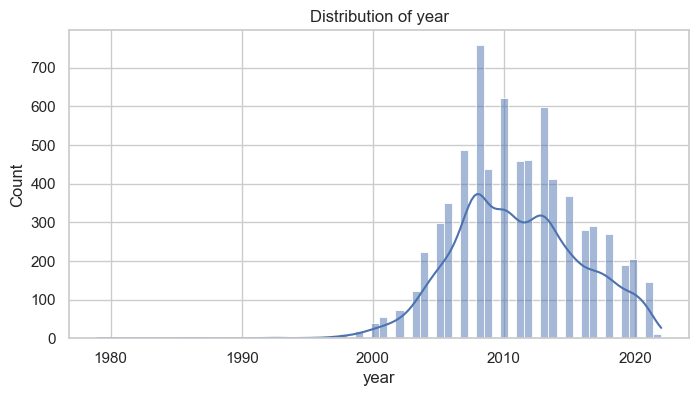

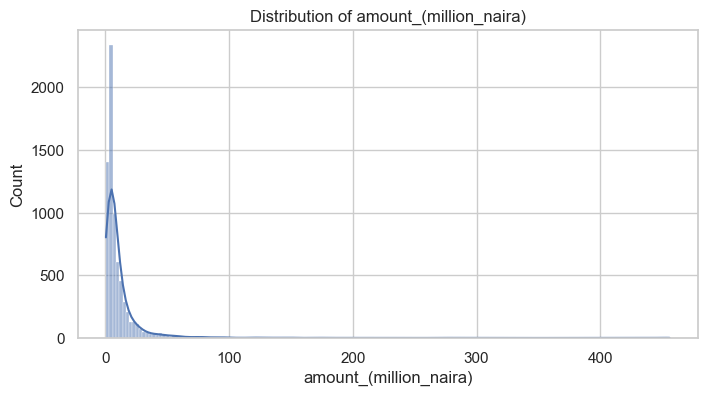

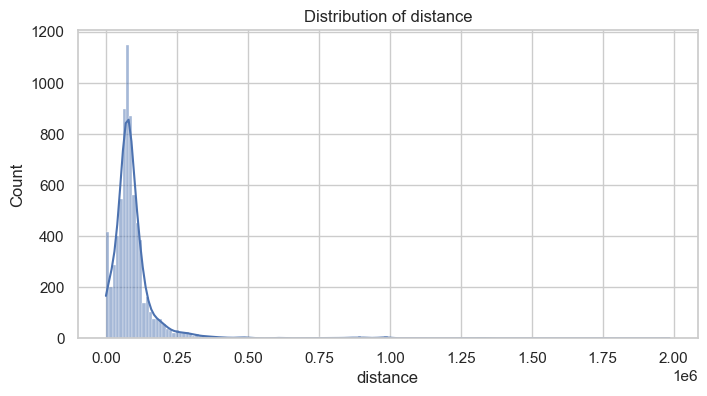

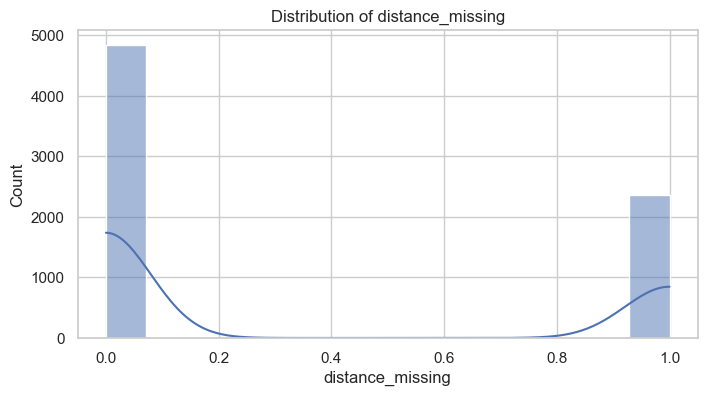

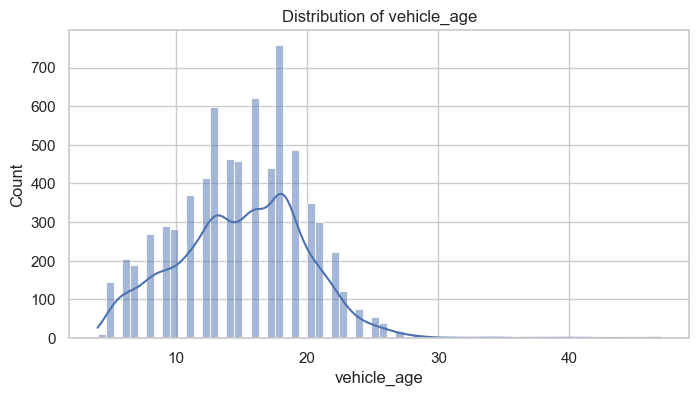

In [288]:
# 6.4 Distribution of Numerical Variables


for col in numerical_columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

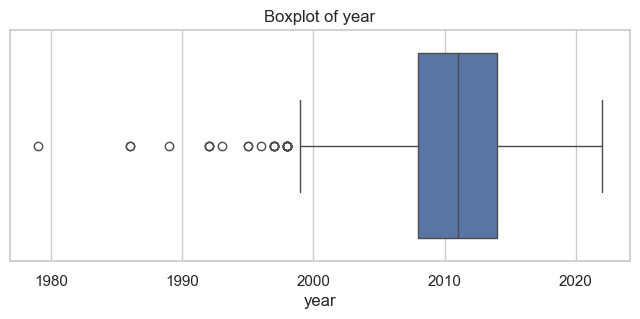

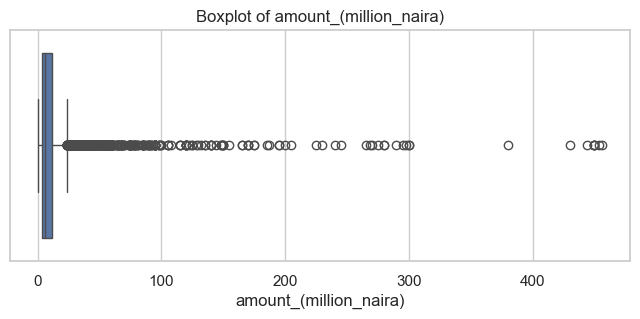

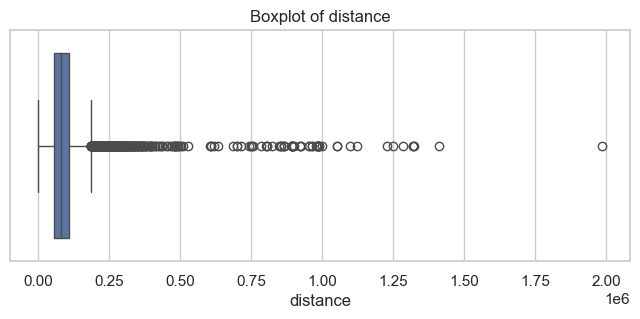

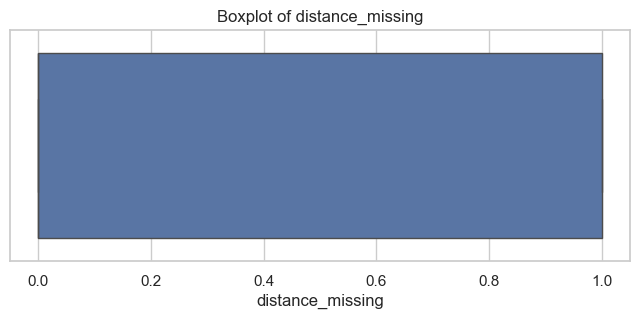

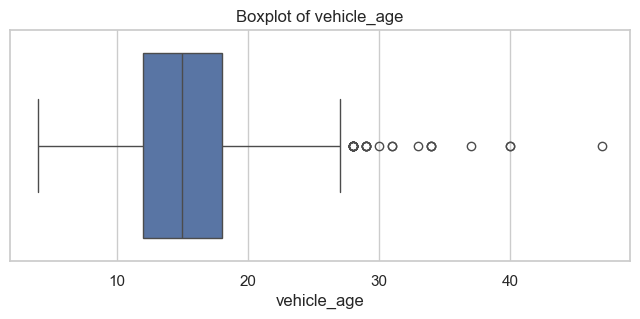

In [289]:
# 6.5 Boxplots for Outlier Detection


for col in numerical_columns:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

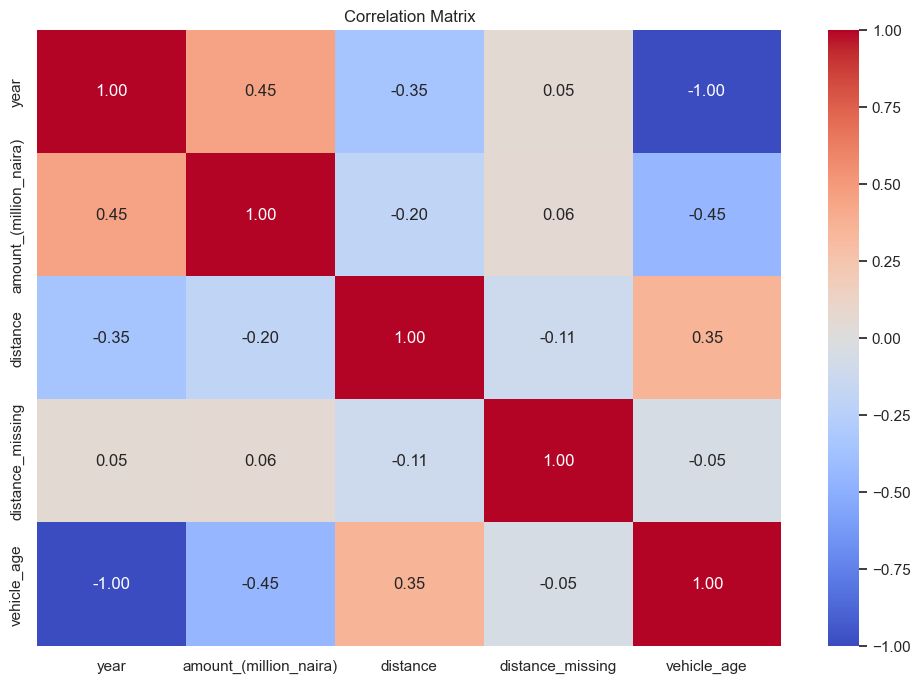

In [ ]:
# 6.6 Correlation Matrix


plt.figure(figsize=(10,6))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

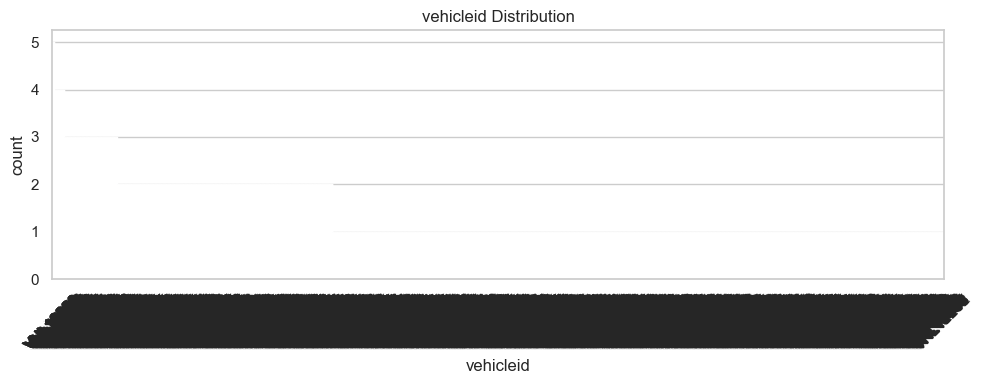

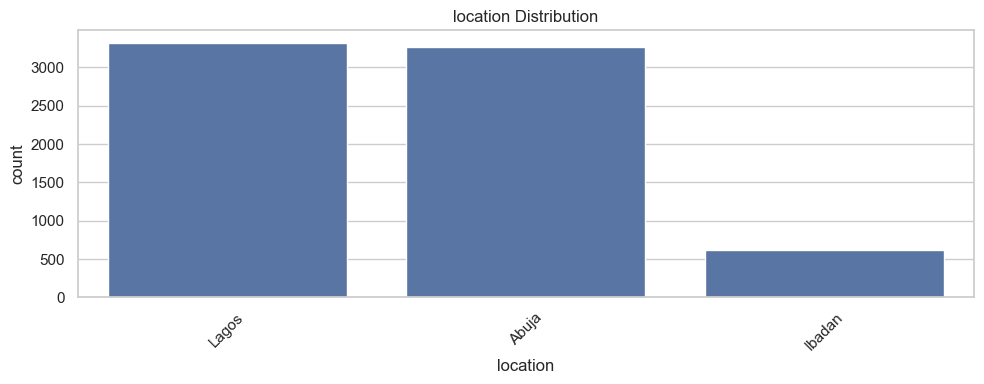

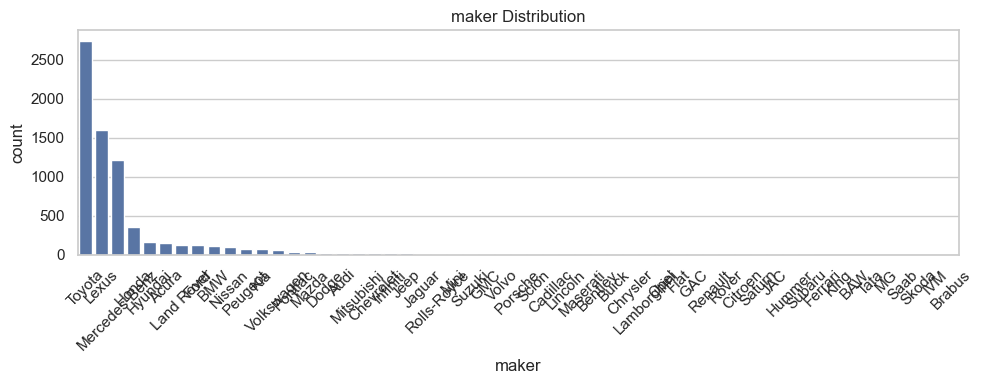

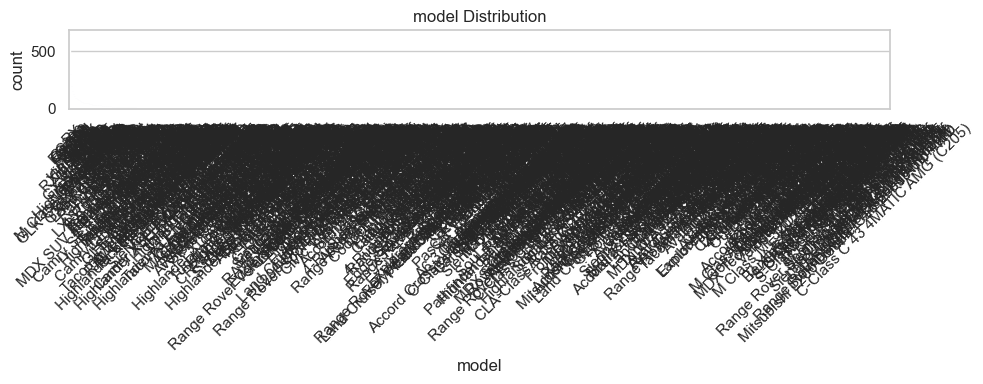

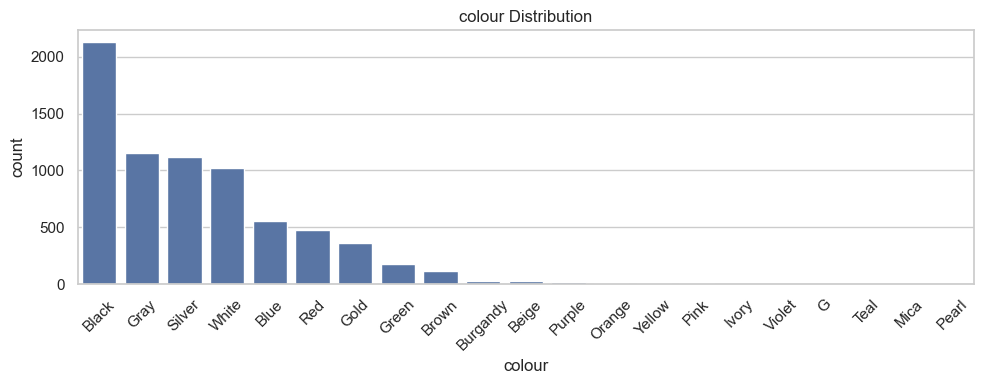

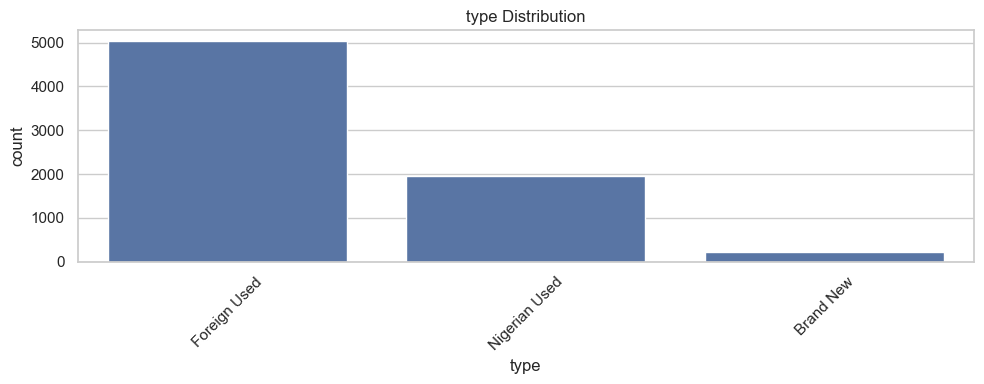

In [291]:
# 6.7 Frequency Distribution of Categorical Variables


for col in categorical_columns:
    plt.figure(figsize=(10,4))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.xticks(rotation=45)
    plt.title(f"{col} Distribution")
    plt.tight_layout()
    plt.show()

#### Step 7 Business Insights from EDA

In [292]:
# 7.1 Correlation with Selling Price

# STEP 7: BUSINESS INSIGHTS FROM EDA

# Correlation with target variable
correlation = (
    df.corr(numeric_only=True)["amount_(million_naira)"]
      .sort_values(ascending=False)
)

print(correlation)

amount_(million_naira)    1.00
year                      0.45
distance_missing          0.06
distance                 -0.20
vehicle_age              -0.45
Name: amount_(million_naira), dtype: float64


In [293]:
# 7.2 Average Selling Price by Brand

brand_price = (
    df.groupby("model")["amount_(million_naira)"]
      .mean()
      .sort_values(ascending=False)
)

print(brand_price)

model
Rolls-Royce Ghost           452.00
Brabus Rocket 900           450.00
Rolls-Royce Phantom         445.33
Rolls-Royce Cullinan Base   444.00
Phantom Base EWB            380.00
                             ...  
Corolla 1.3 Liftback          0.70
Camry Station Wagon           0.69
Tiida                         0.68
Sentra 1.8 S                  0.62
318i                          0.56
Name: amount_(million_naira), Length: 1223, dtype: float64


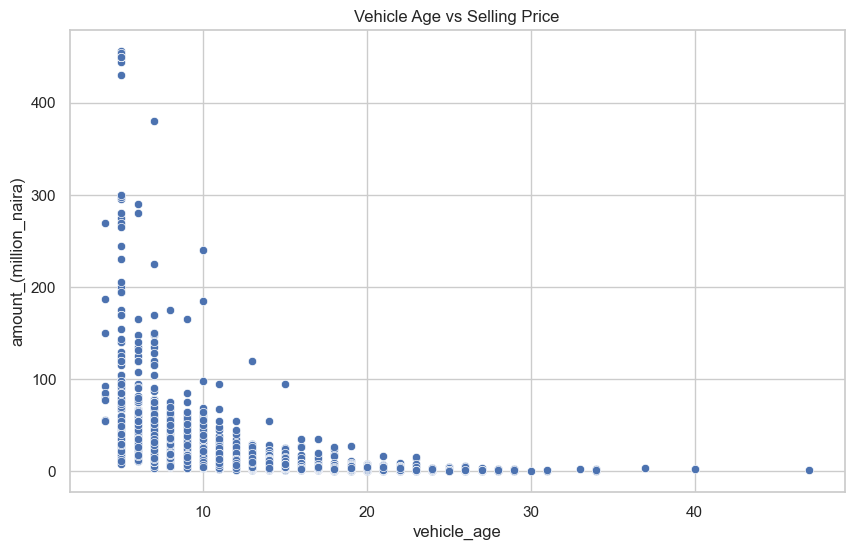

In [294]:
# 7.5 Relationship Between Vehicle Age and Selling Price

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="vehicle_age",
    y="amount_(million_naira)"
)

plt.title("Vehicle Age vs Selling Price")
plt.show()

In [295]:
# Please Note: A temporary distance_missing indicator was created during data cleaning to identify the missig distance covered 
# by some vehicles. After imputation validation, the helper column was removed before model development, because it was used just 
# asertain missing distance values that were imputed.

# Remove distance_missing

df.drop(columns=['distance_missing'], inplace=True)

# Verify removal

print(df.columns)

Index(['vehicleid', 'location', 'maker', 'model', 'year', 'colour',
       'amount_(million_naira)', 'type', 'distance', 'vehicle_age'],
      dtype='str')


In [298]:
# Drop Vehicle identifier column

df.drop(columns=['vehicleid'], inplace=True)

# df = df.drop(columns=["VehicleID"])

In [299]:
# Convert and save dataset as csv

df.to_csv(r'C:\Users\Emeka\Desktop\car\df.csv', index=False)

#### Step 8 Feature Selection

In [300]:

# Separate the predictors (X) from the target (y).

# STEP 8: FEATURE SELECTION

# Target Variable
target = "amount_(million_naira)"

# Features
X = df.drop(columns=[target])

# Target
y = df[target]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (7205, 8)
Target Shape : (7205,)


In [301]:
# 8.1 Identify Numerical Features

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_features

['year', 'distance', 'vehicle_age']

In [302]:
# 8.2 Identify Categorical Features

categorical_features = X.select_dtypes(include="object").columns.tolist()

categorical_features

['location', 'maker', 'model', 'colour', 'type']

#### Step 9 Train-Test Split

In [ ]:
# STEP 9: TRAIN-TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (5764, 8)
Testing Set : (1441, 8)


In [ ]:
# We have total of 7,205 observations ( 5764 + 1441 = 7205)
# Training Set: (5764, 8)
# Testing Set: (1441, 8)

#### Step 10 Build the Preprocessing Pipeline

In [ ]:
# This is the industrial approach.

# STEP 10: PREPROCESSING PIPELINE

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [316]:
# Numerical Pipeline

numeric_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="median")),

        ("scaler", StandardScaler())

    ]

)

In [317]:
# Categorical Pipeline

categorical_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="most_frequent")),

        ("encoder", OneHotEncoder(handle_unknown="ignore"))

    ]

)

In [318]:
# Combine Both Pipelines

preprocessor = ColumnTransformer(

    transformers=[

        ("num", numeric_transformer, numeric_features),

        ("cat", categorical_transformer, categorical_features)

    ]

)

In [319]:
# Verify the Pipeline

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

#### Step 11 Build Machine Learning Models

In [ ]:


# I will compare several regression algorithms.

# STEP 11: MACHINE LEARNING MODELS

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

Create Pipelines for Each Model

In [321]:
# Linear Regression

linear_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", LinearRegression())

    ]

)

In [322]:
# Ridge Regression

ridge_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", Ridge())

    ]

)

In [324]:
# Lasso Regression

lasso_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", Lasso())

    ]

)

In [326]:
# Decision Tree

tree_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", DecisionTreeRegressor(random_state=42))

    ]

)

In [327]:
# Random Forest

forest_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", RandomForestRegressor(random_state=42))

    ]

)

In [328]:
# Gradient Boosting

boost_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", GradientBoostingRegressor(random_state=42))

    ]

)

#### Step 12 Train the Models

In [ ]:

# STEP 12: TRAIN THE MODELS

models = {

    "Linear Regression": linear_model,

    "Ridge Regression": ridge_model,

    "Lasso Regression": lasso_model,

    "Decision Tree": tree_model,

    "Random Forest": forest_model,

    "Gradient Boosting": boost_model

}

In [330]:
# Train All Models

for name, model in models.items():

    model.fit(X_train, y_train)

    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Ridge Regression trained successfully.
Lasso Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [331]:
# Verify One Model

print(models["Random Forest"])

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'distance',
                                                   'vehicle_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'

In [ ]:
# I have successfully completed the following
# Business insight generation from EDA
# Selected the features and target variable.
# Split the data into training and testing sets.
# Built a reusable preprocessing pipeline.
# Defined six regression models.
# Trained all six models using the same preprocessing workflow.

# In the next section steps, I will evaluate each model using MAE, MSE, 
# RMSE, R², and cross-validation, compare the models,  plot Actual vs Predicted price graph, 
# visualize feature importance and residuals, tune  the best-performing model with GridSearchCV,
# save the final model with joblib. Confirm the choosen model by making predictions on new vehicles. 
# Make business recommendations and project limitations

#### Step 13 Model Evaluation

In [ ]:
# Import Libraries

# STEP 13: MODEL EVALUATION

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import cross_val_score

import numpy as np

In [ ]:
# 13.1 Evaluate all models

results = []

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Cross Validation
    cv_score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    ).mean()

    results.append([
        name,
        mae,
        mse,
        rmse,
        r2,
        cv_score
    ])

In [334]:
# 13.2 Create Evaluation Table

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R² Score",
        "CV R²"
    ]
)

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

results_df

,Model,MAE,MSE,RMSE,R² Score,CV R²
4,Random Forest,2.96,115.38,10.74,0.84,0.70
0,Linear Regression,4.32,138.35,11.76,0.80,0.65
5,Gradient Boosting,4.34,138.99,11.79,0.80,0.69
1,Ridge Regression,4.70,146.06,12.09,0.79,0.66
3,Decision Tree,3.46,166.74,12.91,0.76,0.61
2,Lasso Regression,7.89,506.59,22.51,0.28,0.30


In [335]:
# Best Model

best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Random Forest


#### Step 14 Residual Analysis

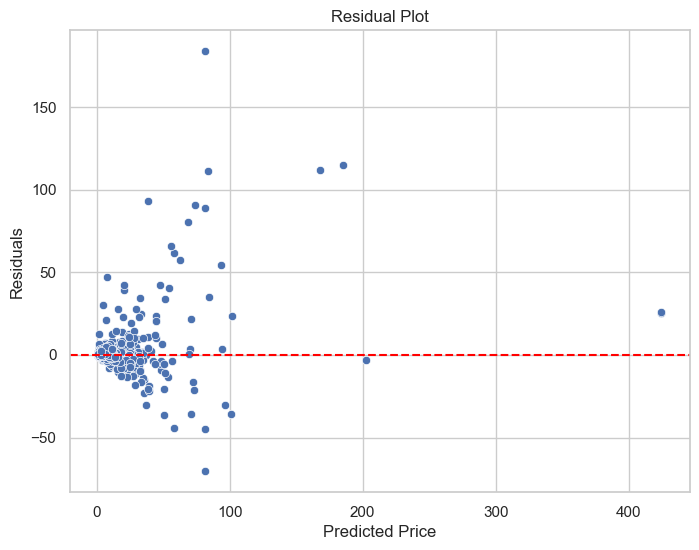

In [336]:
# residual Plot

best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

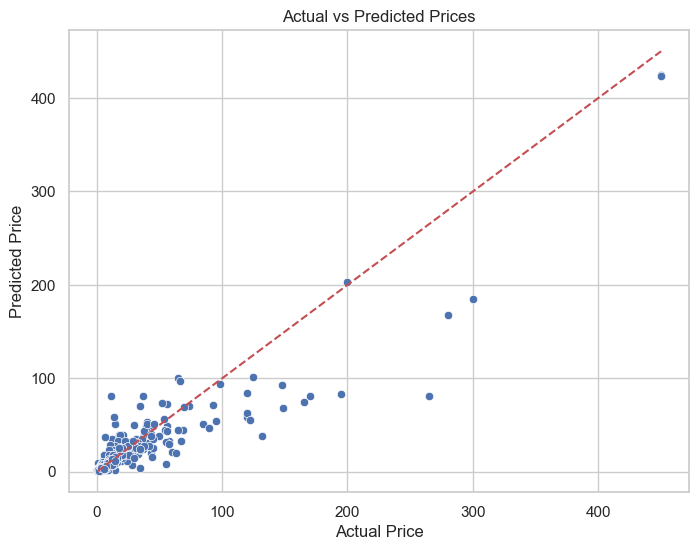

In [337]:
# Actual vs Predicted

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

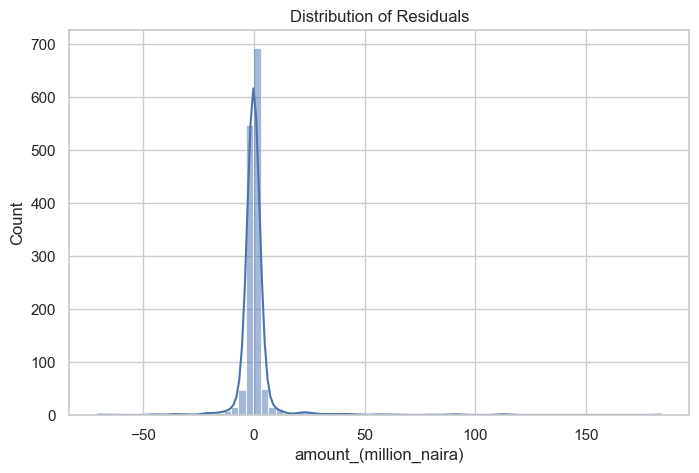

In [338]:
# Distribution of Residuals

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Distribution of Residuals")

plt.show()

#### Step 15 Feature Importance

In [339]:
# This applies on to Tree-based Model

tree_models = [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting"
]

if best_model_name in tree_models:

    model = best_model.named_steps["model"]

    preprocessor = best_model.named_steps["preprocessor"]

    feature_names = preprocessor.get_feature_names_out()

    importance = pd.DataFrame({

        "Feature": feature_names,

        "Importance": model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    importance.head(20)

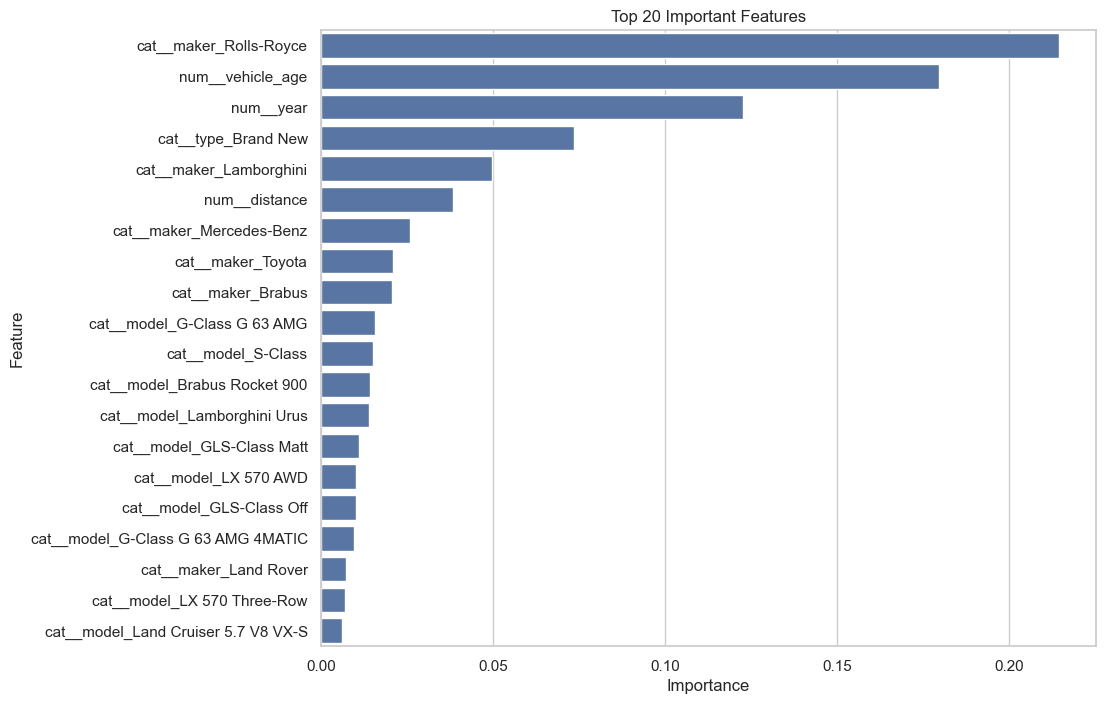

In [340]:
# Plot Top 20 Features

plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Important Features")

plt.show()

#### Step 16 Hyperparameter Tuning

In [341]:
# Here we tune the Best Model : Random Forest.

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [342]:
rf_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", RandomForestRegressor(random_state=42))

    ]

)

In [343]:
param_grid = {

    "model__n_estimators":[100,200,300],

    "model__max_depth":[10,20,None],

    "model__min_samples_split":[2,5,10],

    "model__min_samples_leaf":[1,2,4]

}

In [344]:
# import RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

In [345]:
# Create the randomized

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=20,                    # We are Testing 20 random
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Fit the model
# Please note. it takes from 18 - 35 minutes before executing completely

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [10, 20, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

In [347]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': None}


In [ ]:
# From the above search, the algorithm has searched many combinations and have found 
# the best-performing model ====> The Random Froest Regressor

In [348]:
# Get the best cross-validation score

print("Best CV R Square Score:")
print(random_search.best_score_)

Best CV R Square Score:
0.6987889288608576


#### Step 17 Save the Best Model

In [349]:
# STEP 17: SAVE MODEL


import joblib

best_model = random_search.best_estimator_
joblib.dump(best_model, "car_price_prediction_model.pkl")

['car_price_prediction_model.pkl']

In [350]:
# Load Model Later

loaded_model = joblib.load(
    "car_price_prediction_model.pkl"
)

#### Step 18 Predict Selling Price of a New Vehicle

In [360]:
# Rather than hard-coding values, create a DataFrame that matches the dataset
# columns (excluding the target variable). Use the following "maker", "model", "year", "location"
# "type", "distance". "colour", "vehicle"


import pandas as pd

new_car = pd.DataFrame({
    "location": ["Abuja"],
    "maker": ["Toyota"],
    "model": ["Camry"],
    "year": [2023],
    "colour": ["Black"],
    "type": ["Brand New"],
    "distance": [18],          # or whatever delivery mileage you decide
    "vehicle_age": [1]
})

In [361]:
predicted_price = best_model.predict(new_car)

print(f"Predicted Selling Price: ₦{predicted_price[0]:,.2f} million")

Predicted Selling Price: ₦77.15 million


#### Step 19 Business Interpretation

In [ ]:
# The Random Forest Regressor was selected as the final model because it achieved the 
# highest predictive performance among all evaluated algorithms, with an R² score of 
# approximately 0.81 and the lowest prediction errors (MAE = 3.06 million Naira and RMSE = 11.57 million Naira). 
# The tuned model was then used to estimate the selling price of unseen vehicles. 
# For a sample 2023 Toyota Camry (Brand New, 18 km delivery mileage, Abuja), 
# the model predicted a selling price of approximately ₦77.15 million. The actual price is ₦75.00 million, which is a good prediction
# with difference of ₦2.15 million from the predicted selling price. This demonstrates 
# that the model can estimate market prices for new vehicle listings and support pricing decisions.

# The percentage error is 2.87%
# 
# From Vehicle Price Prediction Leger
# Error less than 5%  ====> Excellent
# Error between 5% and 10% ====> Good
# Error between 10% and 15% ====> Acceptable
# Error above 15% ====> Needs improvement
# 
# With Error 2.8%, the model performance is Excellent 

In [ ]:
# One important correction

# The sample prediction above is only an example. Any vechicle prediction must contain
# exactly the same feature columns as X_train, with the same column names and appropriate 
# data types.

#### Step 20 Business Recommendations

In [ ]:
# Business Recommendations

# • The machine learning model made a good prediction with percentage error is 2.87%, it should be adopted.

# • It is better to have stock of resalable vehcile brand of higher values and demand.

# • The model should be retrained periodically to update the model with new trends in order to maintain better predictions.

# • The prediction should be used as a supporting tool in real life judgement.

# • Further the trained model can be a guide to dealers in make decision fast during business transaction, for example restocking of vehicles.

#### Step 21 Project Conclusion

In [ ]:
# Project Conclusion

# This project successfully developed an end-to-end machine learning solution for
# predicting vehicle selling prices using historical sales data from Nigeria car sales.

# After developing and evaluating uo to 6 models, the best model was selected. 
# The select was based on the evaluation metrics such as MAE, RMSE, R² Score, and cross-validation.

# From my observation, the selected model demonstrated strong predictive capability and can assist dealers 
# buyers, and sellers to make  wise decision in vehcile price prediction.

#### Step 22 Project Limitations and Future Improvements

In [ ]:
# Project Limitations

# • The dataset represents historical sales and may not reflect future market conditions.

# • Vehicle prices are also influenced by economic factors that were not included in the dataset(put in considering Nigerian factor)..

# • Some vehicle attributes such as maintence records were not available.


